In [1]:
import numpy as np
import matplotlib.pyplot as plt
from OptimumFilter import *



sampling_frequency = 3906250
vac_template = np.load("/home/dwong/DELight_mtr/trigger_study/archive/wk15/templates/vac_ch_template.npy")

noise_psd = np.load("/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy")
vac_of = OptimumFilter(vac_template, noise_psd, sampling_frequency)


data = np.load("separate_trace.npz")
signal = data["signal"]
noise = data["noise"]
quantized = data["quantized"] 
unquantized = data["unquantized"] 

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


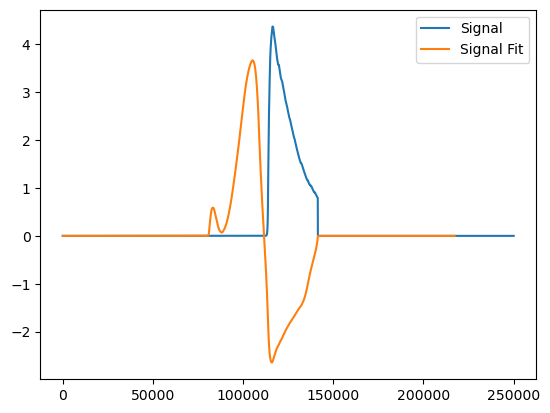

In [2]:
amps_signal, chisq_signal, _ = vac_of.sliding_fit(signal, hop=1)

plt.plot(signal, label="Signal")
plt.plot(amps_signal, label="Signal Fit")

plt.legend()
plt.show()


In [3]:
len(signal)

250000

In [2]:
amps_signal, chisq_signal, _ = vac_of.sliding_fit(signal, hop=1)
amps_noise, chisq_noise, _ = vac_of.sliding_fit(noise, hop=1)
amps_quantized, chisq_quantized, _ = vac_of.sliding_fit(quantized, hop=1)
amps_unquantized, chisq_unquantized, _= vac_of.sliding_fit(unquantized, hop=1)




In [6]:
length = len(vac_template)
if length%2==0:
    noise_psd_unfolded = np.concatenate(([np.inf],
                                                noise_psd[1:-1]/2,
                                                [noise_psd[-1]],
                                                noise_psd[-2:0:-1]/2))
else:
    noise_psd_unfolded = np.concatenate(([np.inf],
                                                noise_psd[1:]/2,
                                                noise_psd[-1:0:-1]/2))
    
template_fft = fft(vac_template)/sampling_frequency

kernel_fft = template_fft.conjugate() / noise_psd_unfolded
kernel_normalization = np.real(np.dot(kernel_fft, template_fft))*sampling_frequency/length 
filter_kernel = kernel_fft / kernel_normalization

In [42]:
trace = signal[118901 : 118901+length]


In [43]:
trace_fft = fft(trace, axis=-1)/sampling_frequency # V
trace_filtered = filter_kernel * trace_fft
amp = np.real(trace_filtered.sum(axis=-1)) * sampling_frequency / length
trace_filtered_td = np.real(
            ifft(trace_filtered, axis=-1)
        ) * sampling_frequency

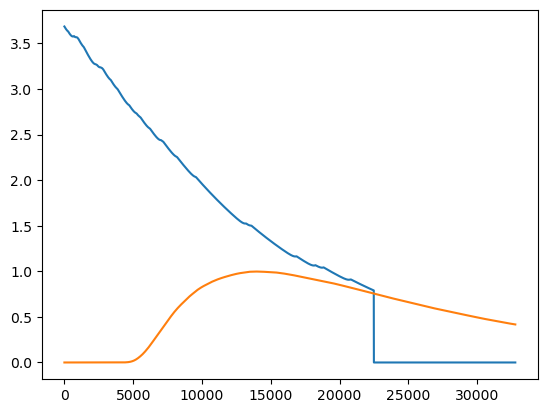

In [44]:
plt.plot(trace)
plt.plot(vac_template)
plt.show()

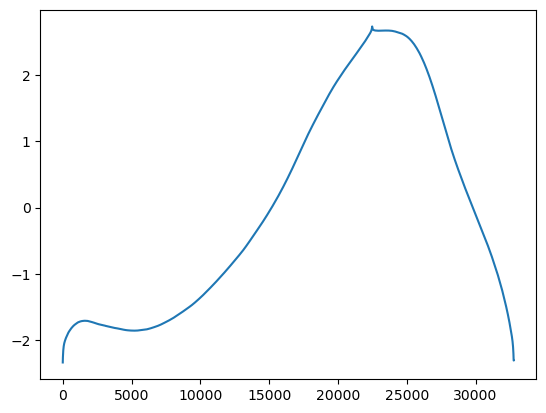

In [46]:
plt.plot(trace_filtered_td)

Most negative response at t0=0: y_min=14299955.906236
Largest positive response at t0=0: y_max=14299955.906236
Amplitude from sum:   -5.560117
Amplitude num/den:    -2.332990  (num=-3.588769e+00, den=1.538270e+00)


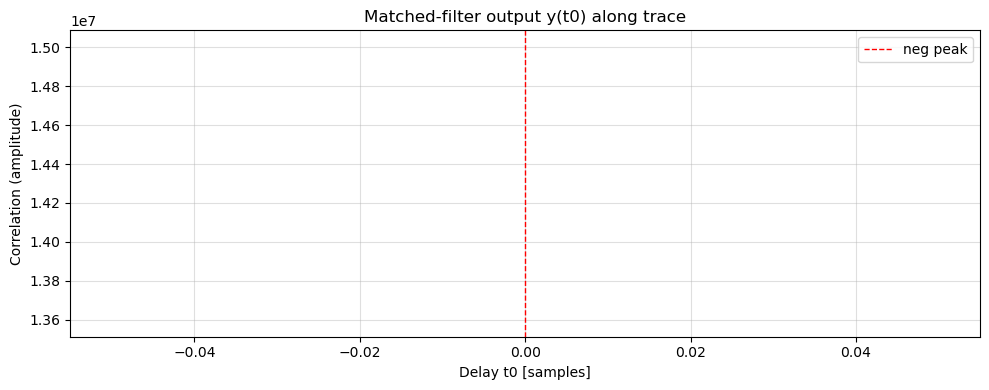

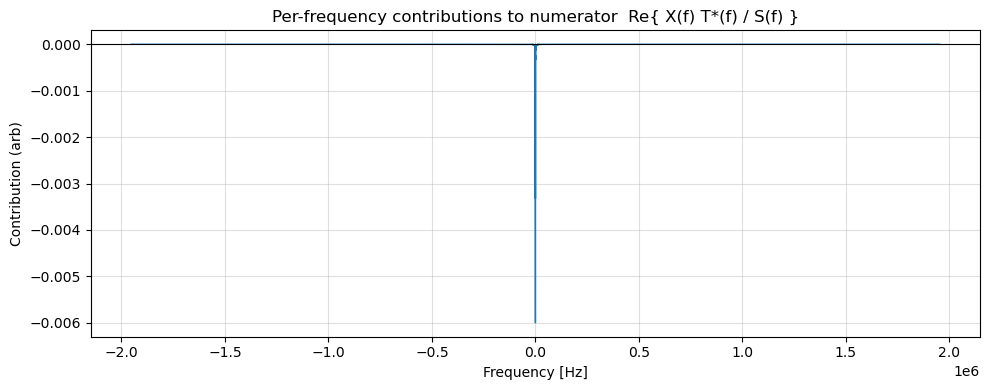

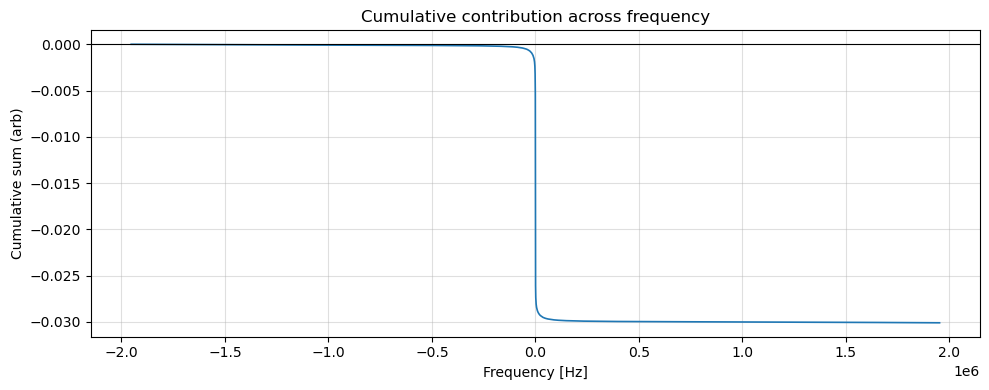

Final cumulative sum (∝ amplitude sign): -3.010478e-02


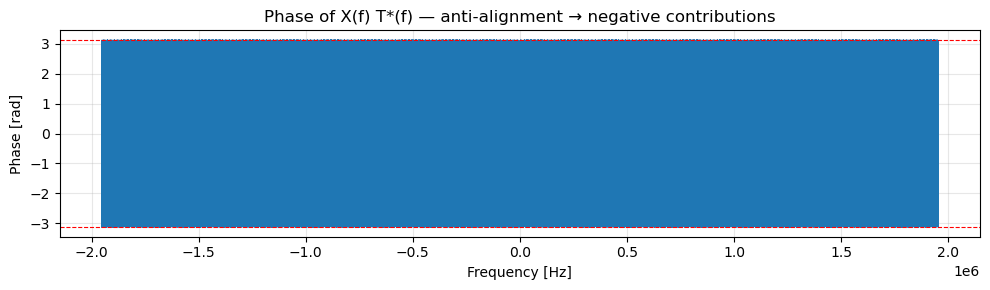

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft, fftfreq
from scipy.signal import fftconvolve

# --- inputs assumed present ---
fs = sampling_frequency              # e.g., 3_906_250
template = vac_template              # 1D template (left-aligned)
psd_one = noise_psd                  # one-sided PSD (rfft length: N//2+1)
x_long = trace                       # <-- set this to your long trace array

# --- helper: unfold one-sided PSD to two-sided for a given N ---
def unfold_psd_to_twosided(psd_one, N):
    # ensure rfft length equals N//2+1
    target = N//2 + 1
    if len(psd_one) < target:
        psd = np.pad(psd_one, (0, target - len(psd_one)), mode="edge")
    else:
        psd = psd_one[:target]
    if N % 2 == 0:
        # [DC, +f (1..N/2-1), Nyq, -f mirror]
        twosided = np.concatenate((
            [np.inf],
            psd[1:-1]/2.0,
            [psd[-1]],
            psd[-2:0:-1]/2.0
        ))
    else:
        # [DC, +f (1..N/2), -f mirror]
        twosided = np.concatenate((
            [np.inf],
            psd[1:]/2.0,
            psd[-1:0:-1]/2.0
        ))
    return twosided  # length N

# --- build OF ingredients for template length N ---
N = len(template)
S2 = unfold_psd_to_twosided(psd_one, N)           # two-sided PSD (length N)
T  = fft(template)/fs                              # template FFT (length N)
H  = np.conj(T) / S2                               # unnormalized kernel in freq
norm = (np.real(np.vdot(H, T)) * fs / N)           # positive scalar
F = H / norm                                       # normalized kernel in freq
h_td = np.real(ifft(F)) * fs                       # time-domain kernel

# --- matched-filter output along the long trace; find most negative point ---
y = fftconvolve(x_long, h_td[::-1], mode="valid")  # correlation vs delay
idx_min = int(np.argmin(y))
idx_max = int(np.argmax(y))
print(f"Most negative response at t0={idx_min}: y_min={y[idx_min]:.6f}")
print(f"Largest positive response at t0={idx_max}: y_max={y[idx_max]:.6f}")

# --- extract the window at the negative peak and analyze in frequency ---
seg = x_long[idx_min : idx_min + N]
X   = fft(seg)/fs

# Per-frequency contributions to the (unnormalized) numerator Re{X T*/S}
contrib = np.real(X * np.conj(T) / S2)            # length N
f = fftfreq(N, d=1/fs)
order = np.argsort(f)
f_ord = f[order]
contrib_ord = contrib[order]
cumsum = np.cumsum(contrib_ord)
phase = np.angle(X * np.conj(T))[order]

# Also compute the scalar amplitude via both ways for consistency
amp_from_sum = np.real((F * X).sum()) * fs / N
num = np.real((X * np.conj(T) / S2).sum()) * fs / N
den = np.real(((np.abs(T)**2) / S2).sum()) * fs / N
amp_from_ratio = num / den
print(f"Amplitude from sum:   {amp_from_sum:.6f}")
print(f"Amplitude num/den:    {amp_from_ratio:.6f}  (num={num:.6e}, den={den:.6e})")

# --- plots ---

# 1) matched-filter output around the negative peak
lo = max(0, idx_min - 3*N//2)
hi = min(len(y), idx_min + 3*N//2)
plt.figure(figsize=(10,4))
plt.plot(np.arange(lo, hi), y[lo:hi], lw=1.2)
plt.axvline(idx_min, color='r', ls='--', lw=1, label="neg peak")
plt.title("Matched-filter output y(t0) along trace")
plt.xlabel("Delay t0 [samples]"); plt.ylabel("Correlation (amplitude)")
plt.grid(True, alpha=0.4); plt.legend(); plt.tight_layout(); plt.show()

# 2) per-frequency contributions Re{X T*/S}
plt.figure(figsize=(10,4))
plt.plot(f_ord, contrib_ord, lw=1.0)
plt.axhline(0, color='k', lw=0.8)
plt.title("Per-frequency contributions to numerator  Re{ X(f) T*(f) / S(f) }")
plt.xlabel("Frequency [Hz]"); plt.ylabel("Contribution (arb)")
plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

# 3) cumulative sum across frequency (sign driver)
plt.figure(figsize=(10,4))
plt.plot(f_ord, cumsum, lw=1.2)
plt.axhline(0, color='k', lw=0.8)
plt.title("Cumulative contribution across frequency")
plt.xlabel("Frequency [Hz]"); plt.ylabel("Cumulative sum (arb)")
plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()
print(f"Final cumulative sum (∝ amplitude sign): {cumsum[-1]:.6e}")

# 4) phase of X·T* (anti-aligned bands ≈ ±π)
plt.figure(figsize=(10,3))
plt.plot(f_ord, phase, lw=0.8)
plt.axhline(np.pi,  color='r', ls='--', lw=0.8)
plt.axhline(-np.pi, color='r', ls='--', lw=0.8)
plt.title("Phase of X(f) T*(f) — anti-alignment → negative contributions")
plt.xlabel("Frequency [Hz]"); plt.ylabel("Phase [rad]")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


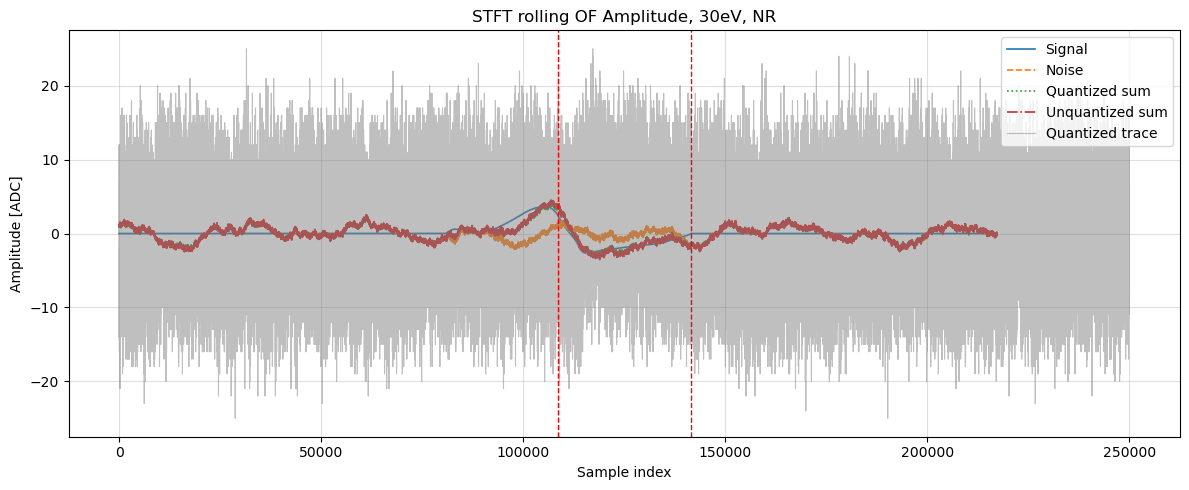

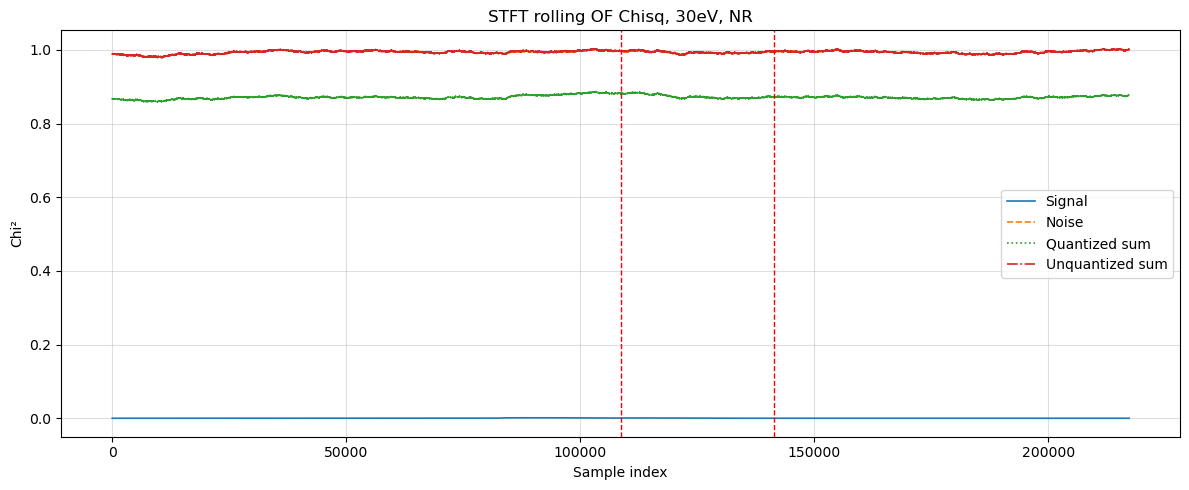

In [ ]:
# --- Amplitudes ---
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(amps_signal,     label="Signal", lw=1.2)
ax.plot(amps_noise,      label="Noise", lw=1.2, linestyle='--')
ax.plot(amps_quantized,  label="Quantized sum", lw=1.2, linestyle=':')
ax.plot(amps_unquantized,label="Unquantized sum", lw=1.2, linestyle='-.')

# Background raw trace (quantized)
ax.plot(quantized, label="Quantized trace", lw=0.8, alpha=0.5, color='gray')

ax.set_xlabel("Sample index")
ax.set_ylabel("Amplitude [ADC]")
ax.set_title("STFT rolling OF Amplitude, 30eV, NR")
ax.grid(True, alpha=0.4)
ax.axvline(108616, color='red', linestyle='--', linewidth=1)
ax.axvline(108616 + 32768, color='red', linestyle='--', linewidth=1)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="best")

fig.tight_layout()
plt.show()


# --- Chi² ---
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(chisq_signal,     label="Signal", lw=1.2)
ax.plot(chisq_noise,      label="Noise", lw=1.2, linestyle='--')
ax.plot(chisq_quantized,  label="Quantized sum", lw=1.2, linestyle=':')
ax.plot(chisq_unquantized,label="Unquantized sum", lw=1.2, linestyle='-.')

# Background raw trace (quantized)

ax.set_xlabel("Sample index")
ax.set_ylabel("Chi²")
ax.set_title("STFT rolling OF Chisq, 30eV, NR")
ax.grid(True, alpha=0.4)
ax.axvline(108616, color='red', linestyle='--', linewidth=1)
ax.axvline(108616 + 32768, color='red', linestyle='--', linewidth=1)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="best")

fig.tight_layout()
plt.show()


In [4]:
print(np.argmin(amps_unquantized))

118901


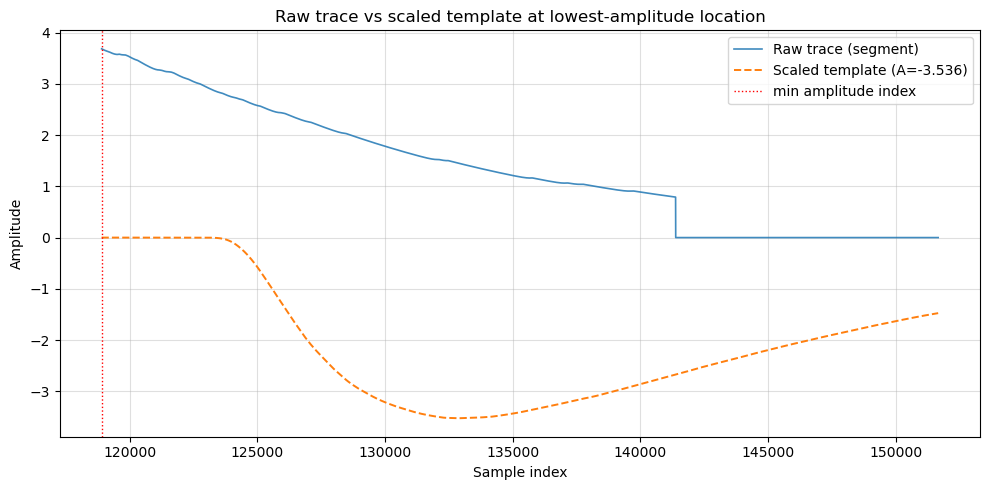

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Inputs assumed available:
# amps_unquantized : 1D array of amplitudes (same length as quantize)
# quantize         : 1D raw trace (long)
# Path to template below

# 1) Find the lowest-amplitude (most negative) point
idx_min = int(np.argmin(amps_unquantized))
amp_min = float(amps_unquantized[idx_min])

# 2) Load template
vac_template = np.load("/home/dwong/DELight_mtr/trigger_study/wk15/templates/vac_ch_template.npy")

# 3) Choose window length (32768 as requested; also ensure not to run past trace end)
WIN = 32768
start = idx_min
end = start + WIN
if end > len(quantized):
    # Shift window left if we would run off the end
    end = len(quantized)
    start = max(0, end - WIN)

# 4) Slice the raw trace segment
trace_seg = signal[start:end]
seg_len = len(trace_seg)

# 5) Scale the template by the amplitude at the valley and left-align to segment
tmpl = vac_template[:seg_len]
template_scaled = amp_min * tmpl

# 6) Plot
plt.figure(figsize=(10, 5))
t = np.arange(start, end)

plt.plot(t, trace_seg, label="Raw trace (segment)", linewidth=1.2, alpha=0.85)
plt.plot(t, template_scaled, label=f"Scaled template (A={amp_min:.3f})", linewidth=1.4, linestyle="--")

# Optional: mark the global minimum index
plt.axvline(idx_min, color="r", linestyle=":", linewidth=1, label="min amplitude index")

plt.title("Raw trace vs scaled template at lowest-amplitude location")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


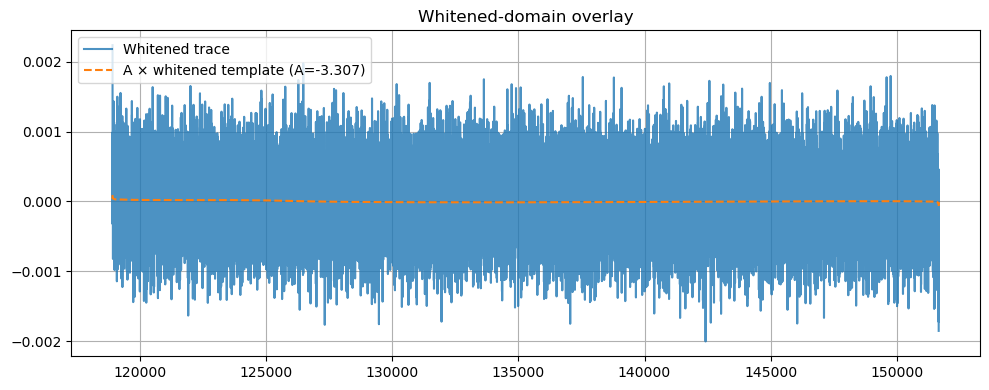

In [14]:
import numpy as np
from numpy.fft import fft, ifft

fs = sampling_frequency
noise_psd = np.load("/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy")
S = noise_psd_unfolded


T = vac_template               # or the exact template used by the OF
seg = quantized[start:end]      # your 32768-sample segment aligned at t0

# Whiten trace and template
X = fft(seg)/fs
Tf = fft(T[:len(seg)])/fs
Wtrace = ifft(X/np.sqrt(S[:len(X)]))         # whitened trace (time domain)
Wtempl = ifft(Tf/np.sqrt(S[:len(Tf)]))       # whitened template (time domain)

# OF amplitude is just the dot product in whitened space
A_of = np.vdot(Wtempl, Wtrace).real / np.vdot(Wtempl, Wtempl).real

# Plot whitened comparison
t = np.arange(start, end)
plt.figure(figsize=(10,4))
plt.plot(t, Wtrace.real, label="Whitened trace", alpha=0.8)
plt.plot(t, (A_of*Wtempl).real, '--', label=f"A × whitened template (A={A_of:.3f})")
plt.legend(); plt.title("Whitened-domain overlay"); plt.grid(True); plt.tight_layout(); plt.show()


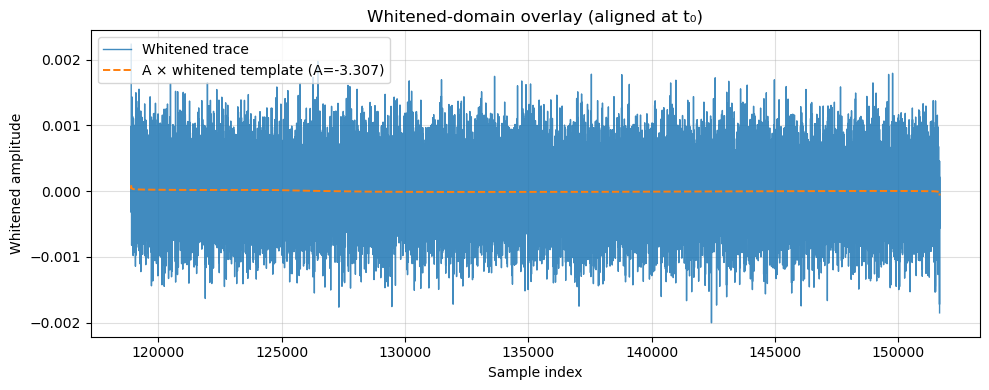

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, ifft

fs = sampling_frequency           # e.g. 3_906_250
tmpl = vac_template               # same template used in OF (left-aligned)
N = 32768                         # window length

# --- pick t0 (best alignment) ---
# e.g. use your already computed arrays:
# t0 = int(np.argmin(chisq_trace))  # or np.argmax(ampl_trace)
t0 = 118901   # <-- replace with your index

start = max(0, t0)                  # left-aligned template starts at t0
end   = start + N
if end > len(quantized):
    end = len(quantized)
    start = end - N

seg = quantized[start:end]
tmpl_w = tmpl[:N]                   # left-aligned to window

# --- build two-sided PSD for this N (unfold + pad) ---
psd_onesided = np.load("/home/dwong/DELight_mtr/templates/noise_psd_from_MMC.npy")
def unfold_to_twosided(psd1):
    # psd1 is one-sided (len = N//2+1 for the design N of the PSD)
    # We’ll resample by padding to match current N in rfft sense:
    target_len = N//2 + 1
    if len(psd1) < target_len:
        psd1 = np.pad(psd1, (0, target_len - len(psd1)), mode="edge")
    elif len(psd1) > target_len:
        psd1 = psd1[:target_len]
    # make two-sided array length N
    dc = np.array([np.inf])                    # ignore DC
    nyq = np.array([psd1[-1]]) if (N % 2 == 0) else np.array([])
    pos = psd1[1: -1 if (N % 2 == 0) else None] / 2.0
    neg = pos[::-1]                            # mirror
    twosided = np.concatenate([dc, pos, nyq, neg])
    return twosided

S2 = unfold_to_twosided(psd_onesided)          # length N, two-sided

# --- whitening (consistent FFT normalization) ---
X  = fft(seg) / fs
Tf = fft(tmpl_w) / fs

# avoid divide-by-zero: S2[0]=inf by construction; others must be >0
Wtrace = ifft(X / np.sqrt(S2))
Wtempl = ifft(Tf / np.sqrt(S2))

# --- OF amplitude in whitened domain ---
num = np.vdot(Wtempl, Wtrace).real
den = np.vdot(Wtempl, Wtempl).real
A_of = num / den

# --- plot whitened overlay ---
t = np.arange(start, end)
plt.figure(figsize=(10,4))
plt.plot(t, Wtrace.real, label="Whitened trace", alpha=0.85, lw=1.0)
plt.plot(t, (A_of * Wtempl).real, '--', label=f"A × whitened template (A={A_of:.3f})", lw=1.4)
plt.title("Whitened-domain overlay (aligned at t₀)")
plt.xlabel("Sample index"); plt.ylabel("Whitened amplitude")
plt.grid(True, alpha=0.4); plt.legend(); plt.tight_layout(); plt.show()


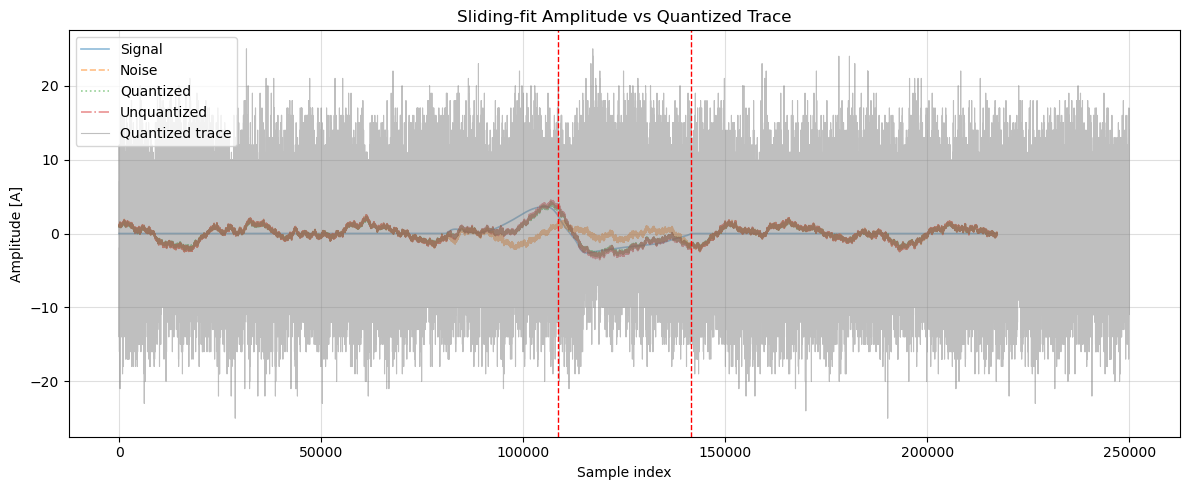

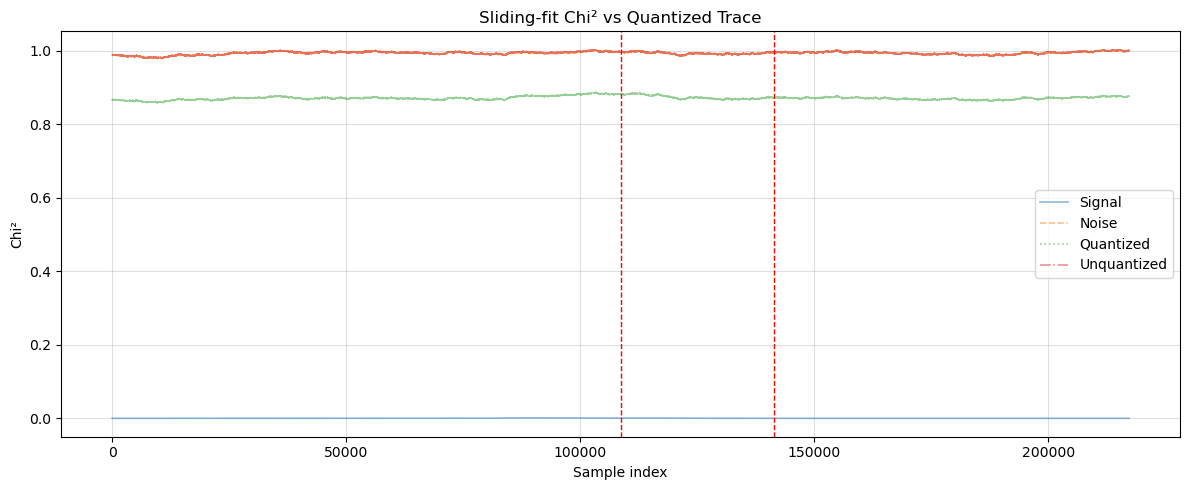

In [10]:
# --- Amplitudes ---
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(amps_signal,      label="Signal",      lw=1.2, alpha=0.5)
ax.plot(amps_noise,       label="Noise",       lw=1.2, linestyle='--', alpha=0.5)
ax.plot(amps_quantized,   label="Quantized",   lw=1.2, linestyle=':', alpha=0.5)
ax.plot(amps_unquantized, label="Unquantized", lw=1.2, linestyle='-.', alpha=0.5)

# Background raw trace (quantized)
ax.plot(quantized, label="Quantized trace", lw=0.8, alpha=0.5, color='gray')

# Red vertical lines
ax.axvline(108616, color='red', linestyle='--', linewidth=1)
ax.axvline(108616 + 32768, color='red', linestyle='--', linewidth=1)

ax.set_xlabel("Sample index")
ax.set_ylabel("Amplitude [A]")
ax.set_title("Sliding-fit Amplitude vs Quantized Trace")
ax.grid(True, alpha=0.4)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="best")

fig.tight_layout()
plt.show()


# --- Chi² ---
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(chisq_signal,      label="Signal",      lw=1.2, alpha=0.5)
ax.plot(chisq_noise,       label="Noise",       lw=1.2, linestyle='--', alpha=0.5)
ax.plot(chisq_quantized,   label="Quantized",   lw=1.2, linestyle=':', alpha=0.5)
ax.plot(chisq_unquantized, label="Unquantized", lw=1.2, linestyle='-.', alpha=0.5)

# Red vertical lines
ax.axvline(108616, color='red', linestyle='--', linewidth=1)
ax.axvline(108616 + 32768, color='red', linestyle='--', linewidth=1)

ax.set_xlabel("Sample index")
ax.set_ylabel("Chi²")
ax.set_title("Sliding-fit Chi² vs Quantized Trace")
ax.grid(True, alpha=0.4)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc="best")

fig.tight_layout()
plt.show()


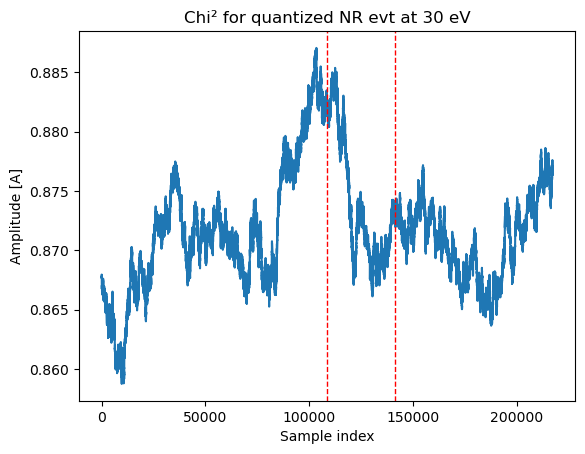

In [19]:
plt.plot(chisq_quantized)
plt.axvline(108616, color='red', linestyle='--', linewidth=1)
plt.axvline(108616 + 32768, color='red', linestyle='--', linewidth=1)
plt.xlabel("Sample index")
plt.ylabel("Amplitude [A]")
plt.title("Chi² for quantized NR evt at 30 eV")
plt.show()


In [21]:
print(np.argmin(amps_signal))

115939


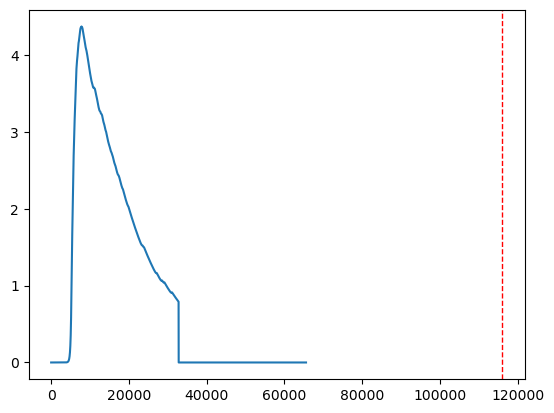

In [27]:
plt.plot(signal[108616:108616 + 32768*2])
plt.axvline(115939, color='red', linestyle='--', linewidth=1)
plt.show()

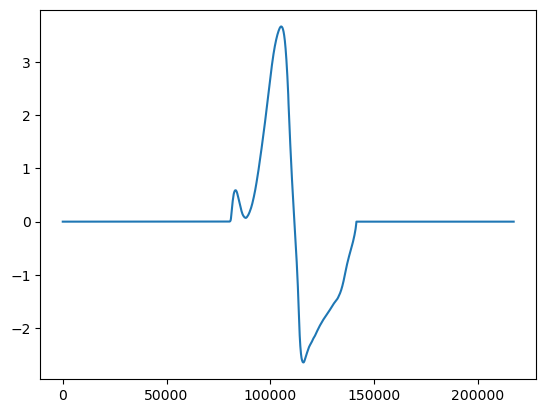

In [29]:
plt.plot(amps_signal)